# PDE test cases: Galerkin residual assembly and boundary conditions

This notebook is a design shakedown for `archimedes.experimental.approximation`,
picking up from the polynomial chaos tutorial (`pce.ipynb`) with two boundary-value
problems that exercise a different part of the design: assembling a *nonlinear*
Galerkin residual and imposing Dirichlet boundary conditions.

Two problems, deliberately similar in structure so the two solution strategies can be
compared directly:

1. A **nonlinear spectral Galerkin** BVP on a global (modal) `OrthogonalPolynomialBasis`.
2. A **nonlinear FEM Poisson** problem on a local (nodal) `PiecewiseBasis`.

Both are solved with a single small helper, `galerkin_test`, built entirely from
`FunctionSpace`/`Basis` methods that are already public -- no new abstraction was
needed. Boundary conditions are imposed by *boundary-bordering*: build the natural
n_basis-length residual for the space, then splice in the BC equations at a
designated set of rows. Which rows depends on whether the basis is modal or nodal:

- **Modal** (`OrthogonalPolynomialBasis`): there's no basis function tied to a
  spatial location, so `boundary_dofs()` returns `(None, None)` and there is no
  natural row to replace. The classical fix is the **tau method**: drop Galerkin
  testing against the highest-degree modes and use those equation slots for the BCs
  instead, evaluated directly via `u(x_bc, deriv=k)`.
- **Nodal** (`PiecewiseBasis` of Lagrange elements): `boundary_dofs()` gives the
  exact global coefficient index that *is* the boundary value, so Dirichlet is just
  overwriting that row with `c[dof] - g`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes.experimental.approximation import (
    Function,
    FunctionSpace,
    LagrangeBasis,
    OrthogonalPolynomialBasis,
    PiecewiseBasis,
)
from archimedes.measure import LegendreMeasure, UnitInterval
from archimedes.quadrature import integral

## `FunctionSpace` primitives: a revision history

This section went through four iterations before landing where it is now, and the
history is worth keeping rather than editing away, since each step was a genuine
correction rather than just polish:

1. **First pass**: a user-level `galerkin_test` helper, reaching into
   `space.quad_rule`/`domain_kwargs` by hand, closing with "no new abstraction was
   needed."
2. **Promoted to `FunctionSpace.galerkin`**: that conclusion was incomplete --
   `galerkin_test`'s `phi.T @ (w[:, None] * phi)` contraction was *already*
   duplicated inside `mass_matrix`, `stiffness_matrix`, and `project`. It wasn't a
   new concept, it was a sixth copy of one, so it was promoted to a method,
   `test_deriv` replacing the ad hoc `deriv` kwarg.
3. **Removed again, in favor of three smaller pieces**: `galerkin` still baked in a
   methodological choice -- *test against your own space's basis* -- and a stress
   test (Problem C below) showed that once a constraint doesn't fit that shape,
   `galerkin` buys nothing for the part that's actually quirky. It became
   `FunctionSpace.quadrature()` (nodes/weights), `FunctionSpace.design_matrix()`
   (the ownership-aware design matrix -- replacing an earlier idea of building it
   from `Function(np.eye(n_basis), space)`, confirmed to silently mis-integrate a
   discontinuous basis under a duplicate-node quadrature rule, off by 12 in one
   direct test), and a free function `archimedes.quadrature.contract(phi, w,
   values)` for the actual contraction. `mass_matrix`/`stiffness_matrix` were
   removed outright: neither had a real consumer anywhere in this library, its
   tests, or its tutorials beyond their own unit tests, and each was one line from
   the new primitives, so shipping them added two names that quietly endorsed one
   specific linear-PDE discretization for a convenience a user reconstructs
   trivially. A `TestFunction`/`inner(..., v)*dx` sugar layer on top of `galerkin`
   was prototyped and dropped at the same stage: it added a footgun (`inner(values,
   v)` trusting that `values` was sampled at `v.space`'s own points, with nothing
   checking it) for a small, narrow readability win.
4. **`design_matrix`/`contract` collapsed into one bundled object,
   `BasisMatrix`**: `phi` and its matching quadrature weights always travel
   together -- every call site fetched both from the same `quadrature()` call --
   but `contract(phi, w, values)` still took them as three independent, easily
   mismatched positional arguments, the same footgun shape as the `TestFunction`
   sugar it replaced. Naming `phi`/`w`, `space.basis_matrix()`, and its adjoint
   (which *is* `contract`, precisely: $\langle \Phi c,r\rangle_w = \langle
   c,\Phi^\top r\rangle \Rightarrow \Phi^\top r = \phi^\top(w\odot r)$) gives a
   `.T`/`@` interface where the projection equation reads almost like the math:
   `M = phi.T @ phi.matrix` is the Gram (mass) matrix $\Phi^\top\Phi$,
   `phi.T @ f(x)` is the load vector $\Phi^\top f$. `contract` itself is
   gone -- once bundled, there was no remaining call site for the loose,
   three-argument version, and its ~30-line docstring was doing more work than the
   three lines of linear algebra it explained. `design_matrix` (returning a bare
   array) is gone too, renamed and changed in kind to `basis_matrix` (returning a
   `BasisMatrix`) -- "design" was overloaded with its ordinary engineering
   meaning, and the bare array lost the `.T` pairing that makes the adjoint
   relationship discoverable rather than folklore.

Testing a residual against *every* basis function doesn't need a bespoke method to
be readable, once the pieces are named right: the basis's design matrix already
evaluates every basis function at every quadrature point as one `(npts, n_basis)`
array, so testing against all of them at once is a single contraction,

$$R_i = \int r(x)\,\phi_i^{(k)}(x)\,w(x)\,dx \quad\Longrightarrow\quad
R = \Phi^{(k)\top} (w \odot r(x)),$$

$$R = \texttt{space.basis\_matrix(deriv=k).T @ r(x)}, \qquad
x = \texttt{space.quadrature()[0]}.$$

$\Phi^{(k)}$'s derivative order is independent of whatever derivative order the
*trial* function `u` uses inside `r`, so mixed-order weak forms (e.g. an advection
term $\int u' v\,dx$) are exactly as expressible as matched-order ones (e.g.
Poisson's $\int u' v'\,dx$) -- just by calling `basis_matrix(deriv=...)` with a
different argument, the same way `galerkin`'s `test_deriv` did.

## Problem A: nonlinear spectral Galerkin BVP

$$-u''(x) + u(x)^3 = f(x), \qquad x \in [-1, 1], \qquad u(-1) = u(1) = 0$$

on a global Legendre basis. To check the discretization against something exact, we
pick a manufactured solution $u(x) = 1 - x^2$ and solve for the forcing $f$ that
makes it exact: $f = -u'' + u^3 = 2 + (1-x^2)^3$. A correct solver should recover
$u(x) = 1-x^2$ to (near) machine precision, since it's a degree-2 polynomial and
therefore exactly representable in the basis.

The basis is modal, so `boundary_dofs()` is `(None, None)` -- there's no coefficient
that *is* a boundary value. We use the tau method instead: test the strong-form
residual against every mode via `space_a.basis_matrix().T @ r(x)`, then overwrite the
two highest-degree mode equations with the Dirichlet constraints, evaluated directly
through `u(x_bc)`.

In [2]:
n_basis = 12
basis_a = OrthogonalPolynomialBasis(LegendreMeasure(), n_basis=n_basis)
space_a = FunctionSpace(basis_a, basis_a.Parameters(a=-1.0, b=1.0))

print("boundary_dofs() for a modal basis:", basis_a.boundary_dofs())


def u_exact_a(x):
    return 1 - x**2


def f_manufactured_a(x):
    u_pp = -2 * np.ones_like(x)
    return -u_pp + u_exact_a(x) ** 3

boundary_dofs() for a modal basis: (None, None)


In [3]:
def residual_a(c):
    u = Function(c, space_a)
    x, w = space_a.quadrature()
    r_val = -u(x, deriv=2) + u(x) ** 3 - f_manufactured_a(x)
    r = space_a.basis_matrix().T @ r_val
    # Tau method: replace the top two (highest-mode) equations with the BCs.
    r[-1] = u(np.array([1.0]))[0]
    r[-2] = u(np.array([-1.0]))[0]
    return r


c0_a = np.zeros(space_a.n_basis)
c_sol_a = arc.optimize.root(residual_a, c0_a)
u_sol_a = Function(c_sol_a, space_a)

x_check_a = np.linspace(-1, 1, 9)
err_a = np.max(np.abs(u_sol_a(x_check_a) - u_exact_a(x_check_a)))
print(f"max |u_h - u_exact| on check grid: {err_a:.3e}")

max |u_h - u_exact| on check grid: 1.050e-13


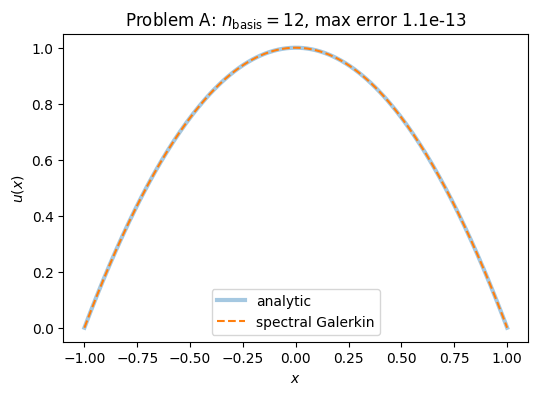

In [4]:
x_plot_a = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_a, u_exact_a(x_plot_a), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_a, u_sol_a(x_plot_a), "--", label="spectral Galerkin")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(f"Problem A: $n_{{\\mathrm{{basis}}}}={n_basis}$, max error {err_a:.1e}")
ax.legend()
plt.show()

## Problem B: nonlinear FEM Poisson

$$-\big((1+u(x)^2)\,u'(x)\big)' = f(x), \qquad x \in [0, 1], \qquad u(0) = u(1) = 0$$

on a `PiecewiseBasis` of quadratic Lagrange elements with $C^0$ continuity. Piecewise
polynomial elements don't have a meaningful strong-form second derivative at element
boundaries, so this is discretized in *weak* (variational) form via integration by
parts: multiply by a test function $v$ and integrate,

$$\int (1+u^2)\,u'\,v'\,dx = \int f\,v\,dx,$$

which is exactly `space_b.basis_matrix(deriv=1).T @ r(x)` on both sides -- testing
against the *derivative* of the basis rather than the basis itself, since the
derivative is what survived the integration by parts.

Manufactured solution: $u(x) = x(1-x)$, giving
$f(x) = -\big[2u\,(u')^2 + (1+u^2)\,u''\big]$ with $u'=1-2x$, $u''=-2$.

Unlike Problem A, this basis is nodal: `boundary_dofs()` (just fixed on
`PiecewiseBasis` -- it previously always returned `(None, None)`, even under
`continuity=0` with an element basis that has well-defined endpoint DOFs) gives the
exact global coefficient indices for $u(0)$ and $u(1)$, so Dirichlet is a direct row
replacement, no tau-style bookkeeping required.

In [5]:
element = LagrangeBasis(reference_nodes=np.array([-1.0, 0.0, 1.0]))  # quadratic
breakpoints = np.linspace(-1, 1, 11)  # 10 elements
basis_b = PiecewiseBasis(element, breakpoints, continuity=0)
space_b = FunctionSpace(basis_b, UnitInterval.Parameters(a=0.0, b=1.0))

left, right = basis_b.boundary_dofs()
print(f"boundary_dofs() for the tiled/assembled basis: ({left}, {right})")
print(f"n_basis = {space_b.n_basis}")


def u_exact_b(x):
    return x * (1 - x)


def k_coef(u):
    return 1 + u**2


def f_manufactured_b(x):
    u = u_exact_b(x)
    u_p = 1 - 2 * x
    u_pp = -2 * np.ones_like(x)
    return -(2 * u * u_p**2 + k_coef(u) * u_pp)

boundary_dofs() for the tiled/assembled basis: (0, 20)
n_basis = 21


In [6]:
def residual_b(c):
    u = Function(c, space_b)
    x, w = space_b.quadrature()
    lhs = space_b.basis_matrix(deriv=1).T @ (k_coef(u(x)) * u(x, deriv=1))
    rhs = space_b.basis_matrix().T @ f_manufactured_b(x)
    r = lhs - rhs
    # Essential (Dirichlet) BCs: the boundary DOF's coefficient *is* the value.
    r[left] = c[left] - 0.0
    r[right] = c[right] - 0.0
    return r


c0_b = np.zeros(space_b.n_basis)
c_sol_b = arc.optimize.root(residual_b, c0_b)
u_sol_b = Function(c_sol_b, space_b)

x_check_b = np.linspace(0, 1, 11)
err_b = np.max(np.abs(u_sol_b(x_check_b) - u_exact_b(x_check_b)))
print(f"max |u_h - u_exact| on check grid: {err_b:.3e}")

max |u_h - u_exact| on check grid: 8.327e-17


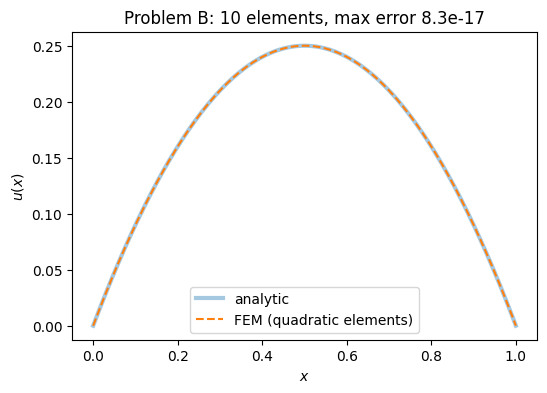

In [7]:
x_plot_b = np.linspace(0, 1, 200)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(x_plot_b, u_exact_b(x_plot_b), lw=3, alpha=0.4, label="analytic")
ax.plot(x_plot_b, u_sol_b(x_plot_b), "--", label="FEM (quadratic elements)")
ax.set_xlabel("$x$")
ax.set_ylabel("$u(x)$")
ax.set_title(
    f"Problem B: {basis_b.n_elements} elements, max error {err_b:.1e}"
)
ax.legend()
plt.show()

## Summary so far

Both problems recover their manufactured (low-degree polynomial) solutions to
essentially machine precision, which is the expected result when the exact solution
lies exactly in the discrete space -- a useful correctness check for the assembly
pattern itself, independent of discretization error.

Boundary-bordering generalizes cleanly across modal (tau method: replace the
top-mode equations) and nodal (`boundary_dofs()`: replace the exact DOF row)
formulations, dispatching on the same `boundary_dofs()` property either way. Both
are still hand-rolled `r[...] = ...` assignments in this notebook -- the next
section builds a small declarative helper for exactly that, and a later one
(Problem C) stress-tests whether it actually generalizes.

## Prototype: `DirichletBC`/`apply_bcs`

Both problems still impose Dirichlet BCs by hand: `idx = np.arange(...)` plus one
`np.where` per boundary, with the *row* (`n_basis - 1`/`n_basis - 2` for the tau
method, `left`/`right` for the nodal case) and the *value expression*
(`u(x_bc, deriv=k)` vs. `c[dof]`) both computed differently depending on which kind
of basis is in play -- even though `boundary_dofs()` already knows which case applies.

The two value expressions turn out to be the same expression, not just similar ones:
a nodal basis's boundary coefficient *is* `u` evaluated there by construction
(`ell_i(x_j) = delta_ij`), so `u(x_bc, deriv=0)` and `c[dof]` agree to the bit for a
nodal basis. That means the only real dispatch left is *which row* a condition lands
in -- `boundary_dofs()`'s own DOF for a nodal end, or a borrowed top-mode row (the tau
method) for a modal one:

In [8]:
from dataclasses import dataclass


@dataclass(frozen=True)
class DirichletBC:
    x: float
    value: float = 0.0
    deriv: int = 0  # 0 for a normal Dirichlet condition


def apply_bcs(r, u: Function, space: FunctionSpace, bcs: list[DirichletBC]):
    """Boundary-border `r` with one essential BC per end of `space`'s domain,
    supplied in `bcs` in the same (left, right) order as
    `space.basis.boundary_dofs()`. A nodal end overwrites that DOF's own
    equation row; a modal end borrows the highest-degree equation rows in
    order (the tau method) -- the same dispatch both problems above already
    made by hand, now driven entirely by `boundary_dofs()`."""
    dofs = space.basis.boundary_dofs()
    tau_slot = space.n_basis
    for bc, dof in zip(bcs, dofs):
        if dof is None:
            tau_slot -= 1
            dof = tau_slot
        r[dof] = u(np.array([bc.x]), deriv=bc.deriv)[0] - bc.value
    return r

Re-solving both problems with it: the BC block in each residual collapses from an
`idx = np.arange(...)` plus two `np.where` calls to a single `apply_bcs(...)` call,
with the tau-vs-nodal distinction no longer written out anywhere in user code.

In [9]:
def residual_a_bc(c):
    u = Function(c, space_a)
    x, w = space_a.quadrature()
    r_val = -u(x, deriv=2) + u(x) ** 3 - f_manufactured_a(x)
    r = space_a.basis_matrix().T @ r_val
    return apply_bcs(r, u, space_a, [DirichletBC(-1.0), DirichletBC(1.0)])


def residual_b_bc(c):
    u = Function(c, space_b)
    x, w = space_b.quadrature()
    lhs = space_b.basis_matrix(deriv=1).T @ (k_coef(u(x)) * u(x, deriv=1))
    rhs = space_b.basis_matrix().T @ f_manufactured_b(x)
    return apply_bcs(lhs - rhs, u, space_b, [DirichletBC(0.0), DirichletBC(1.0)])


c_sol_a_bc = arc.optimize.root(residual_a_bc, np.zeros(space_a.n_basis))
u_sol_a_bc = Function(c_sol_a_bc, space_a)
err_a_bc = np.max(np.abs(u_sol_a_bc(x_check_a) - u_exact_a(x_check_a)))
print(f"Problem A, max |u_h - u_exact|: {err_a_bc:.3e}")

c_sol_b_bc = arc.optimize.root(residual_b_bc, np.zeros(space_b.n_basis))
u_sol_b_bc = Function(c_sol_b_bc, space_b)
err_b_bc = np.max(np.abs(u_sol_b_bc(x_check_b) - u_exact_b(x_check_b)))
print(f"Problem B, max |u_h - u_exact|: {err_b_bc:.3e}")

Problem A, max |u_h - u_exact|: 1.050e-13
Problem B, max |u_h - u_exact|: 8.327e-17


### Scope

Two boundaries worth being explicit about, so this doesn't overreach:

- **One BC per end**, matching `boundary_dofs()`'s 2-tuple. Fine for these
  second-order problems; a 4th-order operator needing two conditions per end would
  need `boundary_dofs()` itself to generalize first (e.g. to also identify a
  first-derivative DOF) -- not needed here, so it's flagged rather than solved.
- **Essential (strong) BCs only** -- row replacement or tau-slot borrowing. A
  Neumann condition in the standard *natural* sense isn't this at all: it's a
  boundary term that falls out of integration by parts and gets added into the
  contracted residual directly, not swapped in as a row afterward. `deriv` on
  `DirichletBC` lets a derivative condition be imposed *strongly* by row
  replacement, which is a valid but different (less standard) technique from
  natural Neumann -- `apply_bcs` doesn't cover the natural case at all.

## Problem C: a stress test for the BC layer

$$-u''(x) + u(x)^2 = f(x), \qquad x \in [-1, 1], \qquad u'(-1) = g_L, \qquad
\int_{-1}^1 u(x)\,dx = 0$$

Problems A and B were "deliberately similar in structure" (per the intro) so that
the *basis* dispatch (modal vs. nodal) could be compared directly -- but that also
means they share exactly one BC topology: two Dirichlet conditions, one per
endpoint. That's the only shape `boundary_dofs()` (a left/right pair) and
`apply_bcs()` (one condition per end, replacing that end's row) were ever tested
against. This problem is chosen to be structurally different in exactly the way that
matters here, rather than just cosmetically:

- **`u'(-1) = g_L` is a Neumann condition**, not a value -- `DirichletBC`'s `deriv`
  field can express it, but it isn't a value at a `boundary_dofs()` slot.
- **The zero-mean constraint isn't associated with an endpoint at all.** It's a
  global integral over the whole domain. There is no "which end does this belong to"
  question to ask `boundary_dofs()` -- it doesn't have a slot for this by
  construction, not by omission.

(A 4th-order operator -- needing two conditions per end -- would be a cleaner
demonstration of `boundary_dofs()`'s 2-tuple shape specifically breaking, but that
needs a Hermite-type basis with derivative DOFs, which isn't implemented yet. This
problem instead stresses the *other* assumption `apply_bcs()` makes: that every
condition is *some* value at *some* point.)

Manufactured solution $u(x) = x^3 + x^2 - 2x - \tfrac13$ has zero mean on $[-1, 1]$
(the odd terms integrate to zero by symmetry, and $x^2 - \tfrac13$ was chosen
specifically so its mean is zero too), and $u'(-1) = -1$, giving $g_L = -1$ and
$f(x) = -(6x + 2) + u(x)^2$.

In [10]:
n_basis_c = 12
basis_c = OrthogonalPolynomialBasis(LegendreMeasure(), n_basis=n_basis_c)
space_c = FunctionSpace(basis_c, basis_c.Parameters(a=-1.0, b=1.0))

g_left = -1.0  # u'(-1)


def u_exact_c(x):
    return x**3 + x**2 - 2 * x - 1 / 3


def f_manufactured_c(x):
    u_pp = 6 * x + 2
    return -u_pp + u_exact_c(x) ** 2

Solved directly against `quadrature`/`basis_matrix`, no BC abstraction at all: just
`boundary_dofs()`-style row-borrowing written by hand, the same mechanism Problem
A's tau method used, holding different content. This is exactly the fallback the
BC-scope note above pointed to: `apply_bcs()` has no way to express either
condition here, so both rows are placed directly.

The zero-mean constraint is a genuine definite integral of a *concrete* function --
not a per-test-function contraction -- so it's the right shape for
`archimedes.quadrature.integral()`: `integral(u, -1.0, 1.0)` reads directly as
$\int_{-1}^1 u\,dx$, closer to the math than dotting quadrature weights against
`u`'s values by hand. It's a legitimate substitute *here* specifically because it's a
scalar functional of one already-built `Function`, the same category as
`Function.norm()`/`FunctionSpace.inner_product()` (which already delegate to
`QuadratureRule.sum()` internally) -- not because it's a general substitute for the
per-test-function contraction above. It explicitly isn't that: `integral()`'s rules
(`legendre`/`radau_left`/`radau_right`/`lobatto`/`clenshaw_curtis`) are all
uniform-weight families, so it can't integrate a Hermite/Jacobi/Laguerre-measure
basis (e.g. the density=True case in `pce.ipynb`) at all; and it has no
`breakpoints`/element concept, so it silently misintegrates a discontinuous
`PiecewiseBasis` exactly the way plain coordinate evaluation used to (confirmed
separately: on a 2-element discontinuous basis, `integral(u, -1, 1, n=40)` disagreed
with the composite-rule-aware value by ~5e-4 even at 40 points) -- the same ownership
issue `basis_matrix` exists specifically to avoid. Since the main residual below
already has `x`/`w` in hand from `space_c.quadrature()`, we use those directly for
the mean constraint too (`np.dot(w, u(x))`) rather than calling `integral()`, which
would discard them and rebuild an unrelated rule for no benefit.

In [11]:
def residual_c(c):
    u = Function(c, space_c)
    x, w = space_c.quadrature()
    r_val = -u(x, deriv=2) + u(x) ** 2 - f_manufactured_c(x)
    r = space_c.basis_matrix().T @ r_val

    # Neither condition is a `boundary_dofs()` value, so there's no dispatch
    # to reuse -- borrow the top two (tau) rows directly by hand.
    r[-1] = u(np.array([-1.0]), deriv=1)[0] - g_left
    r[-2] = np.dot(w, u(x))  # zero-mean constraint, reusing x/w already in hand
    return r


c0_c = np.zeros(space_c.n_basis)
c_sol_c = arc.optimize.root(residual_c, c0_c)
u_sol_c = Function(c_sol_c, space_c)

x_check_c = np.linspace(-1, 1, 9)
err_c = np.max(np.abs(u_sol_c(x_check_c) - u_exact_c(x_check_c)))
print(f"max |u_h - u_exact| on check grid: {err_c:.3e}")

max |u_h - u_exact| on check grid: 2.220e-16


In [12]:
x_c, w_c = space_c.quadrature()
via_dot = np.dot(w_c, u_sol_c(x_c))
via_integral = integral(u_sol_c, -1.0, 1.0)
print(f"zero mean, np.dot(w, u(x)) vs. integral(u, -1, 1): {via_dot:.3e} vs. {via_integral:.3e}")

zero mean, np.dot(w, u(x)) vs. integral(u, -1, 1): -1.110e-16 vs. -7.147e-16


## Final summary

Both stress tests point the same direction, so it's worth stating plainly rather
than re-litigating: **the primitive that survived is the one that never assumed
anything about the problem.**

- `FunctionSpace.quadrature()` and `FunctionSpace.basis_matrix()` are pure
  data-fetching: nodes/weights, and a basis matrix at them. Neither knows or cares
  what the residual looks like, how many boundary conditions there are, or whether
  the test space matches the trial space. They were the same two calls in Problems
  A, B, and C.
- `BasisMatrix.T` (its adjoint, applied via `@`) is pure linear algebra: it doesn't
  know what `phi` is the matrix *of*. That's what let Problem C's
  Neumann-and-integral system fall out of exactly the same call as Problems A/B's
  Dirichlet systems -- the contraction never had an opinion about boundary
  conditions to begin with. It replaced a free function, `contract`, that did the
  same three lines but as three independent, easily mismatched arguments instead
  of a bundle with a name -- a footgun shape, not a simplicity.
- `galerkin()`, `mass_matrix()`, `stiffness_matrix()`, and the `TestFunction`/`inner`
  sugar all failed for the same underlying reason, at different points: each baked
  in a specific *use* of the primitives above (test against your own basis; the
  particular bilinear forms of a linear self-adjoint operator; a wrapper that
  assumed its caller had already gotten the quadrature bookkeeping right) rather
  than the primitives themselves. `mass_matrix`/`stiffness_matrix` additionally had
  zero real consumers to justify the bet. `apply_bcs()`/`DirichletBC` is being kept,
  but demoted in status: it's one example pattern for one BC topology (proven not to
  generalize by Problem C), not shipped as *the* way to impose a boundary condition.

That divide -- primitives that describe *data* (quadrature nodes, a basis matrix,
its adjoint) versus helpers that encode a *method* (Galerkin testing, essential BCs,
a specific bilinear form) -- is a reasonable rule of thumb for what the
`approximation` module should ship going forward. The former composes into whatever
a user is actually trying to build; the latter is exactly the kind of thing FEniCS/
Firedrake already do well, and that one user's convenience is another's obstacle, so
it belongs in a notebook (or a user's own project) rather than the library.